# M2.Ex2: Automobile Fuel Efficiency

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ["mpg", "cylinders", "displacement", "horsepower", "weight",
             "acceleration", "model year", "origin", "car name"]

df = pd.read_csv(url, names=col_names, sep=r"\s+", na_values="?")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = df.drop(columns=["mpg", "car name"])
y = df["mpg"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (398, 7)
y shape: (398,)


### Step 2.b print the type of each

In [4]:
print("Type of X:", type(X))
print("Type of y:", type(y))
print("\nX dtypes:")
print(X.dtypes)

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>

X dtypes:
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model year        int64
origin            int64
dtype: object


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [6]:
print("Target dtype:", y.dtype)
print()
print("The target 'mpg' is NUMERICAL (continuous float).")
print("Therefore, this is a REGRESSION task.")

Target dtype: float64

The target 'mpg' is NUMERICAL (continuous float).
Therefore, this is a REGRESSION task.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [7]:
print(f"X: {X.shape[0]} samples, {X.shape[1]} features")
print(f"y: {y.shape[0]} samples (1 column — target)")

X: 398 samples, 7 features
y: 398 samples (1 column — target)


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [8]:
# Numerical features
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
print("=== Numerical Features ===")
display(X[num_cols].describe())

# Categorical features
# In this dataset, 'origin' is stored as int but represents a category (1=USA, 2=Europe, 3=Japan)
# 'cylinders' is also discrete/categorical in nature
cat_cols = ["cylinders", "origin"]
print("\n=== Categorical Features (as object) ===")
display(X[cat_cols].astype(str).describe())

=== Numerical Features ===


,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000



=== Categorical Features (as object) ===


,cylinders,origin
count,398,398
unique,5,3
top,4,1
freq,204,249


### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

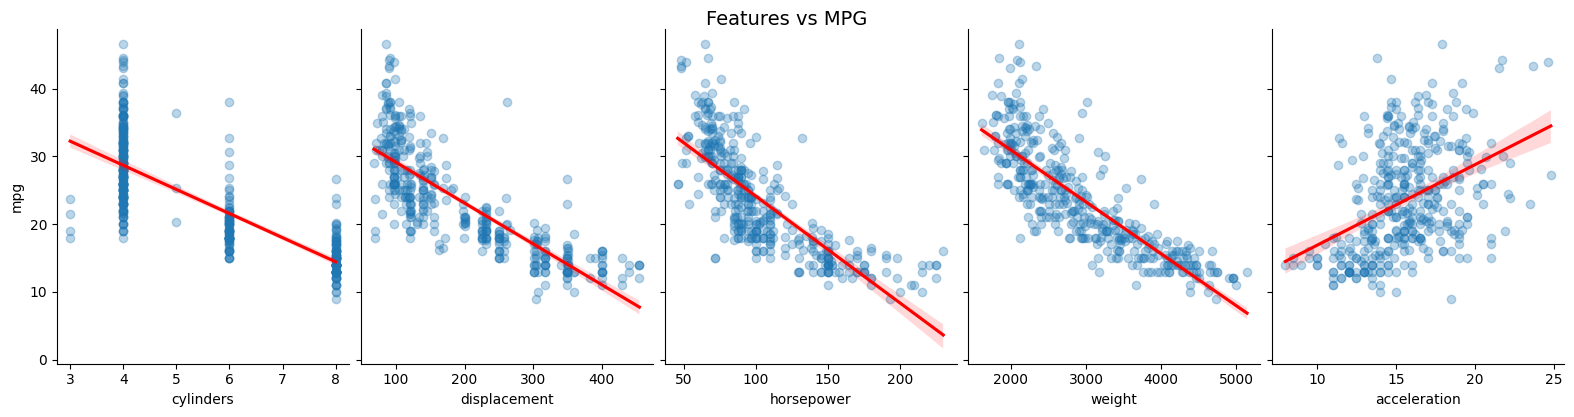

In [9]:
feature_cols = ["cylinders", "displacement", "horsepower", "weight", "acceleration"]

plot_df = X[feature_cols].copy()
plot_df["mpg"] = y

sns.pairplot(
    plot_df,
    x_vars=feature_cols,
    y_vars="mpg",
    height=4,
    aspect=0.8,
    kind="reg",
    plot_kws={"line_kws": {"color": "red"}, "scatter_kws": {"alpha": 0.3}}
)
plt.suptitle("Features vs MPG", y=1.02, fontsize=14)
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

In [10]:
relationships = {
    "cylinders":     "DECREASING — more cylinders → lower mpg (heavier, more powerful engines)",
    "displacement":  "DECREASING — larger engine displacement → lower mpg",
    "horsepower":    "DECREASING — more horsepower → lower mpg",
    "weight":        "DECREASING — heavier cars → lower mpg (strongest negative relationship)",
    "acceleration":  "INCREASING — higher acceleration (slower 0-60) → slightly higher mpg (weak positive)",
}

for feature, relationship in relationships.items():
    print(f"  {feature:15s}: {relationship}")

  cylinders      : DECREASING — more cylinders → lower mpg (heavier, more powerful engines)
  displacement   : DECREASING — larger engine displacement → lower mpg
  horsepower     : DECREASING — more horsepower → lower mpg
  weight         : DECREASING — heavier cars → lower mpg (strongest negative relationship)
  acceleration   : INCREASING — higher acceleration (slower 0-60) → slightly higher mpg (weak positive)


### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [11]:
# Define feature groups
numerical_features   = ["displacement", "horsepower", "weight", "acceleration", "model year"]
categorical_features = ["cylinders", "origin"]

# Numerical pipeline: impute missing values then scale
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# Categorical pipeline: impute then one-hot encode
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Combine with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline,   numerical_features),
    ("cat", categorical_pipeline, categorical_features),
])

predictor = LinearRegression()

In [12]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)

### Step 8. Split the dataset into train and test sets

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test  set: {X_test.shape[0]} samples")

Train set: 318 samples
Test  set: 80 samples


### Step 9.a Fit the pipeline on the training set

In [14]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [15]:
# Get feature names after preprocessing
cat_feature_names = (
    pipe.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
    .tolist()
)
all_feature_names = numerical_features + cat_feature_names

coefficients = pipe.named_steps["regressor"].coef_
intercept    = pipe.named_steps["regressor"].intercept_

coef_df = pd.DataFrame({"Feature": all_feature_names, "Coefficient": coefficients})
coef_df = coef_df.sort_values("Coefficient", key=abs, ascending=False).reset_index(drop=True)

print(f"Bias (intercept): {intercept:.4f}\n")
print("Coefficients:")
display(coef_df)

Bias (intercept): 23.1194

Coefficients:


,Feature,Coefficient
0,weight,-4.944089
1,cylinders_3,-4.780292
2,model year,2.777651
3,cylinders_5,2.216774
4,cylinders_4,2.029147
5,origin_1,-1.576926
6,displacement,1.561228
7,cylinders_8,1.343657
8,horsepower,-1.260555
9,origin_3,1.044218


### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

In [16]:
# The weight coefficient is in standardized units — we need to convert back to raw units.
# After StandardScaler, the scaler's std for 'weight' tells us 1 scaled unit = std lbs.
# The dataset uses lbs, not kg. 100 kg ≈ 220.46 lbs.

weight_std = pipe.named_steps["preprocessor"].named_transformers_["num"].named_steps["scaler"].scale_[
    numerical_features.index("weight")
]

weight_coef = coefficients[numerical_features.index("weight")]

# Change in mpg per 1 raw unit (1 lb) decrease in weight
mpg_per_lb = -weight_coef / weight_std  # negative because we're decreasing weight

# 100 kg in lbs
lbs_100kg = 100 * 2.20462

mpg_gain = mpg_per_lb * lbs_100kg

print(f"Weight coefficient (scaled): {weight_coef:.4f}")
print(f"Weight std (lbs):            {weight_std:.4f}")
print(f"MPG gain per lb decrease:    {mpg_per_lb:.5f}")
print(f"100 kg = {lbs_100kg:.2f} lbs")
print(f"\nDecreasing weight by 100 kg → MPG gain ≈ {mpg_gain:.3f} mpg")

Weight coefficient (scaled): -4.9441
Weight std (lbs):            839.2950
MPG gain per lb decrease:    0.00589
100 kg = 220.46 lbs

Decreasing weight by 100 kg → MPG gain ≈ 1.299 mpg


### Step 10. Evaluate the pipeline on the test set

In [ ]:
score = pipe.score(X_test, y_test)